In [76]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [77]:
X,y = make_blobs(n_samples=100,random_state=42,centers=2,cluster_std=1.2)

In [78]:
y=np.where(y==0,-1,1)   #convert y=(0,1) to y = (-1,1)

In [79]:
n_sample,n_features = X.shape
epochs=1000
alpha = 0.01
lambda_param =0.01

In [80]:
w=np.zeros(n_features)
b=0

In [81]:
for epoch in range(epochs):
    for idx,x_i in enumerate(X):
        condition = y[idx] * (np.dot(x_i,w)+b) >=1

        if condition:
            dw = 2*lambda_param*w
            db=0
        else:
            dw= 2*lambda_param*w - np.dot(x_i,y[idx])
            db=-y[idx]
        w=w-alpha*dw
        b=b-alpha*db

In [82]:
def predict(X):
    output = np.dot(X,w)+b
    return np.sign(output)  #returns -1 for -ve number, +1 for +ve number 

In [83]:
predictions = predict(X)

### !for plot purpose only 

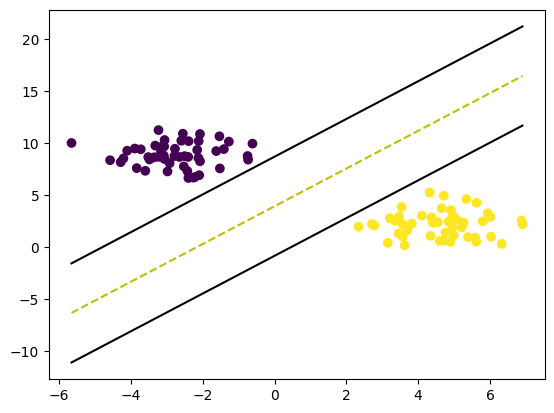

In [84]:
def plot_decision_boundary():

    def hyperplane(x, w, b, offset):
        return (-w[0] * x - b + offset) / w[1]

    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)

    plt.scatter(X[:,0], X[:,1], c=y)

    x0_1 = np.min(X[:,0])
    x0_2 = np.max(X[:,0])

    x1_1 = hyperplane(x0_1, w, b, 0)
    x1_2 = hyperplane(x0_2, w, b, 0)

    x1_1_m = hyperplane(x0_1, w, b, -1)
    x1_2_m = hyperplane(x0_2, w, b, -1)

    x1_1_p = hyperplane(x0_1, w, b, 1)
    x1_2_p = hyperplane(x0_2, w, b, 1)

    ax.plot([x0_1, x0_2], [x1_1, x1_2], "y--")
    ax.plot([x0_1, x0_2], [x1_1_m, x1_2_m], "k")
    ax.plot([x0_1, x0_2], [x1_1_p, x1_2_p], "k")

    plt.show()

plot_decision_boundary()